In [2]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pr.plot_setup()

In [3]:
data, platemap = pr.load_platereader_data(
    data_file="20251027_Broccoli_mScarlet_test.txt", 
    platemap_file="20251027_Broccoli_mScarlet_platemap.tsv", 
    platereader="biotek-cdk"
)
data.to_csv('20251027_Broccoli_mScarlet_data.csv')
data.head

<bound method NDFrame.head of                 Time Well      Data Row  Column      Read    Plate  \
0    0 days 00:00:00   D3     81.00   D       3  mScarlet  Plate 1   
1    0 days 00:05:00   D3     40.00   D       3  mScarlet  Plate 1   
2    0 days 00:10:00   D3     45.00   D       3  mScarlet  Plate 1   
3    0 days 00:15:00   D3     46.00   D       3  mScarlet  Plate 1   
4    0 days 00:20:00   D3     46.00   D       3  mScarlet  Plate 1   
...              ...  ...       ...  ..     ...       ...      ...   
2155 0 days 05:35:31  H11 165490.00   H      11  GFP-Gext  Plate 1   
2156 0 days 05:40:31  H11 165068.00   H      11  GFP-Gext  Plate 1   
2157 0 days 05:45:31  H11 164032.00   H      11  GFP-Gext  Plate 1   
2158 0 days 05:50:31  H11 164358.00   H      11  GFP-Gext  Plate 1   
2159 0 days 05:55:31  H11 163603.00   H      11  GFP-Gext  Plate 1   

              Clock Time  Sample #                       Name  
0    2025-10-27 11:10:28         1                   Negative  
1

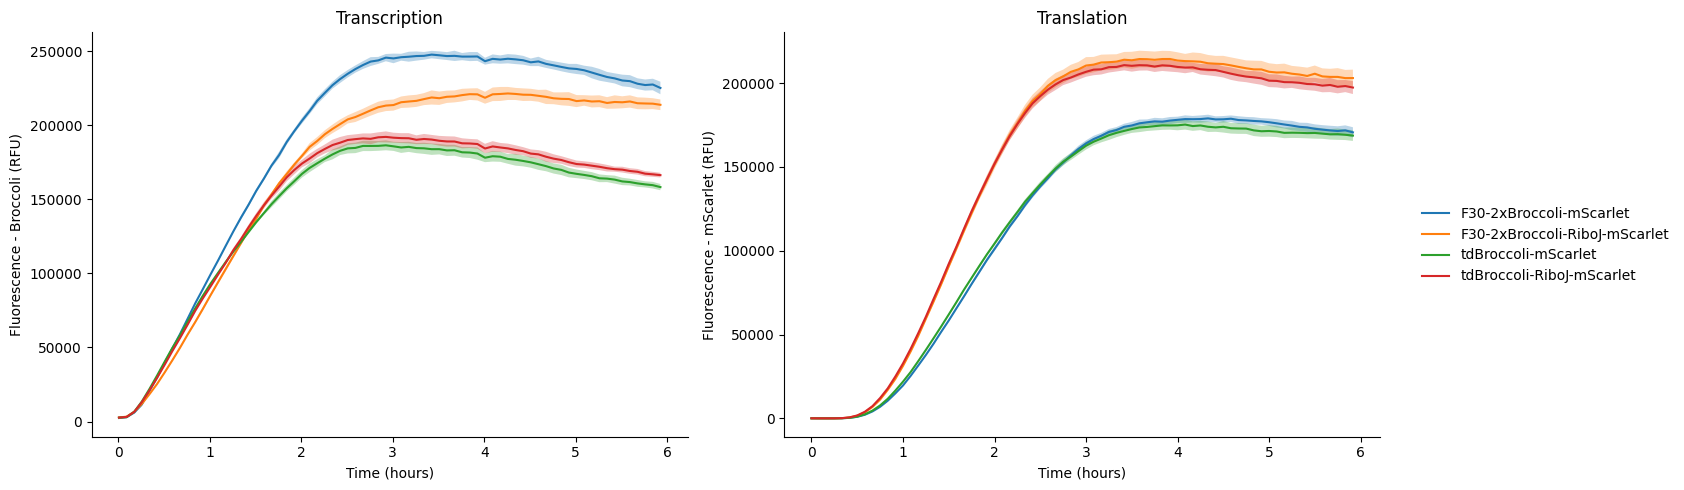

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = data[data["Name"] != "Negative"]["Name"].unique()

# Aptamer (Broccoli)
for name in names:
    subset = data[(data["Read"] == "Aptamer") & (data["Name"] == name)]
    grouped = subset.groupby("Time")["Data"]
    mean = grouped.mean()
    sem = grouped.sem()
    axes[0].plot(mean.index.total_seconds()/3600, mean.values, label=name)
    axes[0].fill_between(mean.index.total_seconds()/3600, mean - sem, mean + sem, alpha=0.3)
axes[0].set_title("Transcription")
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Fluorescence - Broccoli (RFU)")

# mScarlet
for name in names:
    subset = data[(data["Read"] == "mScarlet") & (data["Name"] == name)]
    grouped = subset.groupby("Time")["Data"]
    mean = grouped.mean()
    sem = grouped.sem()
    axes[1].plot(mean.index.total_seconds()/3600, mean.values, label=name)
    axes[1].fill_between(mean.index.total_seconds()/3600, mean - sem, mean + sem, alpha=0.3)
axes[1].set_title("Translation")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Fluorescence - mScarlet (RFU)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [28]:

print(data["Read"].unique())


['mScarlet' 'Aptamer']


ValueError: not enough values to unpack (expected 2, got 0)

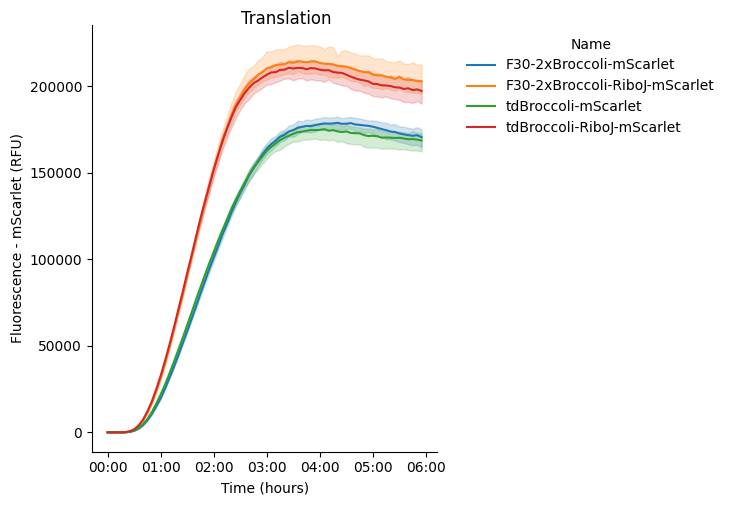

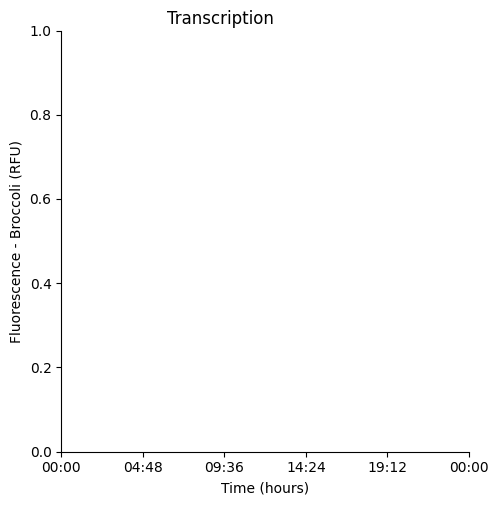

In [19]:
# mScarlet plot
mScarlet_plot = pr.plot_curves(data[(data["Read"] == "mScarlet") & (data["Name"] != "Negative")], hue="Name")
mScarlet_plot.fig.suptitle("Translation", y=1, x=0.45)
mScarlet_plot.ax.set_ylabel("Fluorescence - mScarlet (RFU)")

handles, labels = mScarlet_plot.ax.get_legend_handles_labels()
clean = [(h, l) for h, l in zip(handles, labels) if l != "Read" and l != "mScarlet"]
handles, labels = zip(*clean)
mScarlet_plot.legend.remove()
legend = mScarlet_plot.ax.legend(handles, labels, title="Name", bbox_to_anchor=(1.05, 1), loc="upper left")
legend.get_frame().set_linewidth(0)

# GFP-Gext (Broccoli) plot
Broccoli_plot = pr.plot_curves(data[(data["Read"] == "GFP-Gext") & (data["Name"] != "Negative")], hue="Name")
Broccoli_plot.fig.suptitle("Transcription", y=1, x=0.45)
Broccoli_plot.ax.set_ylabel("Fluorescence - Broccoli (RFU)")

handles, labels = Broccoli_plot.ax.get_legend_handles_labels()
clean = [(h, l) for h, l in zip(handles, labels) if l != "Read" and l != "GFP-Gext"]
handles, labels = zip(*clean)
Broccoli_plot.legend.remove()
legend = Broccoli_plot.ax.legend(handles, labels, title="Name", bbox_to_anchor=(1.05, 1), loc="upper left")
legend.get_frame().set_linewidth(0)

plt.show()

In [5]:
mScarlet_plot=pr.plot_curves(data[data["Name"]!="Negative"], hue="Read", col="Name")

AttributeError: 'DataFrame' object has no attribute 'READ_COLUMN_NAME'

In [6]:
mScarlet_plot=pr.plot_curves(data[data["Name"]!="Negative"], style="Read", hue="Name")

AttributeError: 'DataFrame' object has no attribute 'READ_COLUMN_NAME'

In [7]:
data["Prot"] = data["Name"].str.replace("-RiboJ", "")
data["Read"] = data["Read"].str.replace("GFP-Gext", "Aptamer")
# data["RiboJ"] = data["Name"].str.split("-").str[-2:-1].str.join("-")
mScarlet_plot=pr.plot_curves(data[data["Name"]!="Negative"], style="Read", hue="Name", col="Prot")

AttributeError: 'DataFrame' object has no attribute 'READ_COLUMN_NAME'

In [8]:
pr.kinetic_analysis(data, group_by=["Name", "Read"])
pr.kinetic_analysis_summary(data, group_by=["Name", "Read"])

PROVIDING AVERAGED KINETICS
PROVIDING AVERAGED KINETICS


In [9]:
lags = pr.kinetic_analysis(data, group_by=["Name", "Read"])["Lag"]
lags["Time"].reset_index().pivot(columns="Read", index="Name", values="Time")

PROVIDING AVERAGED KINETICS


Read,Aptamer,mScarlet
Name,,
F30-2xBroccoli-RiboJ-mScarlet,0 days 00:14:36.797863342,0 days 00:54:25.545001935
F30-2xBroccoli-mScarlet,0 days 00:22:15.386211429,0 days 00:53:34.838537419
Negative,-1 days +13:27:20.681095959,0 days 00:05:03.654459325
tdBroccoli-RiboJ-mScarlet,0 days 00:20:17.075282291,0 days 00:53:21.332283999
tdBroccoli-mScarlet,0 days 00:19:57.911891575,0 days 00:50:30.279200283


In [10]:
lags = pr.kinetic_analysis(data, group_by=["Name", "Read"])
lags["Lag"].reset_index().pivot(columns="Read", index="Name", values="Time")

PROVIDING AVERAGED KINETICS


Read,Aptamer,mScarlet
Name,,
F30-2xBroccoli-RiboJ-mScarlet,0 days 00:14:36.797863342,0 days 00:54:25.545001935
F30-2xBroccoli-mScarlet,0 days 00:22:15.386211429,0 days 00:53:34.838537419
Negative,-1 days +13:27:20.681095959,0 days 00:05:03.654459325
tdBroccoli-RiboJ-mScarlet,0 days 00:20:17.075282291,0 days 00:53:21.332283999
tdBroccoli-mScarlet,0 days 00:19:57.911891575,0 days 00:50:30.279200283


In [11]:
lags

Velocity            \
                                                            Time      Data   
Name                          Read                                           
F30-2xBroccoli-RiboJ-mScarlet Aptamer  0 days 01:11:07.032688954 110726.25   
                              mScarlet 0 days 01:37:44.084731224 107519.42   
F30-2xBroccoli-mScarlet       Aptamer  0 days 01:14:32.009019311 123930.46   
                              mScarlet 0 days 01:49:32.590910506  89454.48   
Negative                      Aptamer  0 days 03:00:20.159057845   1311.43   
                              mScarlet 0 days 04:59:45.759258093     37.79   
tdBroccoli-RiboJ-mScarlet     Aptamer  0 days 01:07:17.755051155 101348.18   
                              mScarlet 0 days 01:36:03.649983006 105414.90   
tdBroccoli-mScarlet           Aptamer  0 days 01:05:31.537073823  93453.35   
                              mScarlet 0 days 01:45:31.561500923  87630.55   

                                                                         Lag  \
                                             Max                        Time   
Name                          Read                                             
F30-2xBroccoli-RiboJ-mScarlet Aptamer  117561.19   0 days 00:14:36.797863342   
                              mScarlet 148941.67   0 days 00:54:25.545001935   
F30-2xBroccoli-mScarlet       Aptamer  142235.64   0 days 00:22:15.386211429   
                              mScarlet  95912.09   0 days 00:53:34.838537419   
Negative                      Aptamer     303.66 -1 days +13:27:20.681095959   
                              mScarlet      8.63   0 days 00:05:03.654459325   
tdBroccoli-RiboJ-mScarlet     Aptamer  129324.13   0 days 00:20:17.075282291   
                              mScarlet 148111.95   0 days 00:53:21.332283999   
tdBroccoli-mScarlet           Aptamer  123072.92   0 days 00:19:57.911891575   
                              mScarlet  95550.97   0 days 00:50:30.279200283   

                                                             Steady State  \
                                           Data                      Time   
Name                          Read                                          
F30-2xBroccoli-RiboJ-mScarlet Aptamer  16358.08 0 days 02:34:18.202472568   
                              mScarlet 24531.51 0 days 02:41:29.705564807   
F30-2xBroccoli-mScarlet       Aptamer  30579.70 0 days 02:31:29.806247596   
                              mScarlet 16267.67 0 days 03:11:55.939394613   
Negative                      Aptamer   3145.20 0 days 22:57:14.257204275   
                              mScarlet    50.37 0 days 12:13:37.698559065   
tdBroccoli-RiboJ-mScarlet     Aptamer  27251.37 0 days 02:16:30.414780521   
                              mScarlet 23980.42 0 days 02:38:55.944036996   
tdBroccoli-mScarlet           Aptamer  28563.40 0 days 02:12:36.033344115   
                              mScarlet 15279.27 0 days 03:06:31.773644165   

                                                  \
                                            Data   
Name                          Read                 
F30-2xBroccoli-RiboJ-mScarlet Aptamer  210379.88   
                              mScarlet 204286.90   
F30-2xBroccoli-mScarlet       Aptamer  235467.87   
                              mScarlet 169963.52   
Negative                      Aptamer    2491.72   
                              mScarlet     71.80   
tdBroccoli-RiboJ-mScarlet     Aptamer  192561.54   
                              mScarlet 200288.31   
tdBroccoli-mScarlet           Aptamer  177561.36   
                              mScarlet 166498.04   

                                                                                      Fit  \
                                                                                   params   
Name                          Read                                                          
F30-2xBroccoli-RiboJ-mScarlet Aptamer   [2

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x7ff9c10c11d0>,
                                                         Velocity            \
                                                             Time      Data   
 Name                          Read                                           
 F30-2xBroccoli-RiboJ-mScarlet Aptamer  0 days 01:11:07.032688954 110726.25   
                               mScarlet 0 days 01:37:44.084731224 107519.42   
 F30-2xBroccoli-mScarlet       Aptamer  0 days 01:14:32.009019311 123930.46   
                               mScarlet 0 days 01:49:32.590910506  89454.48   
 Negative                      Aptamer  0 days 03:00:20.159057845   1311.43   
                               mScarlet 0 days 04:59:45.759258093     37.79   
 tdBroccoli-RiboJ-mScarlet     Aptamer  0 days 01:07:17.755051155 101348.18   
                               mScarlet 0 days 01:36:03.649983006 105414.90   
 tdBroccoli-mScarlet           Aptamer  0 days 01:05:31.537073823  93453.35   
   

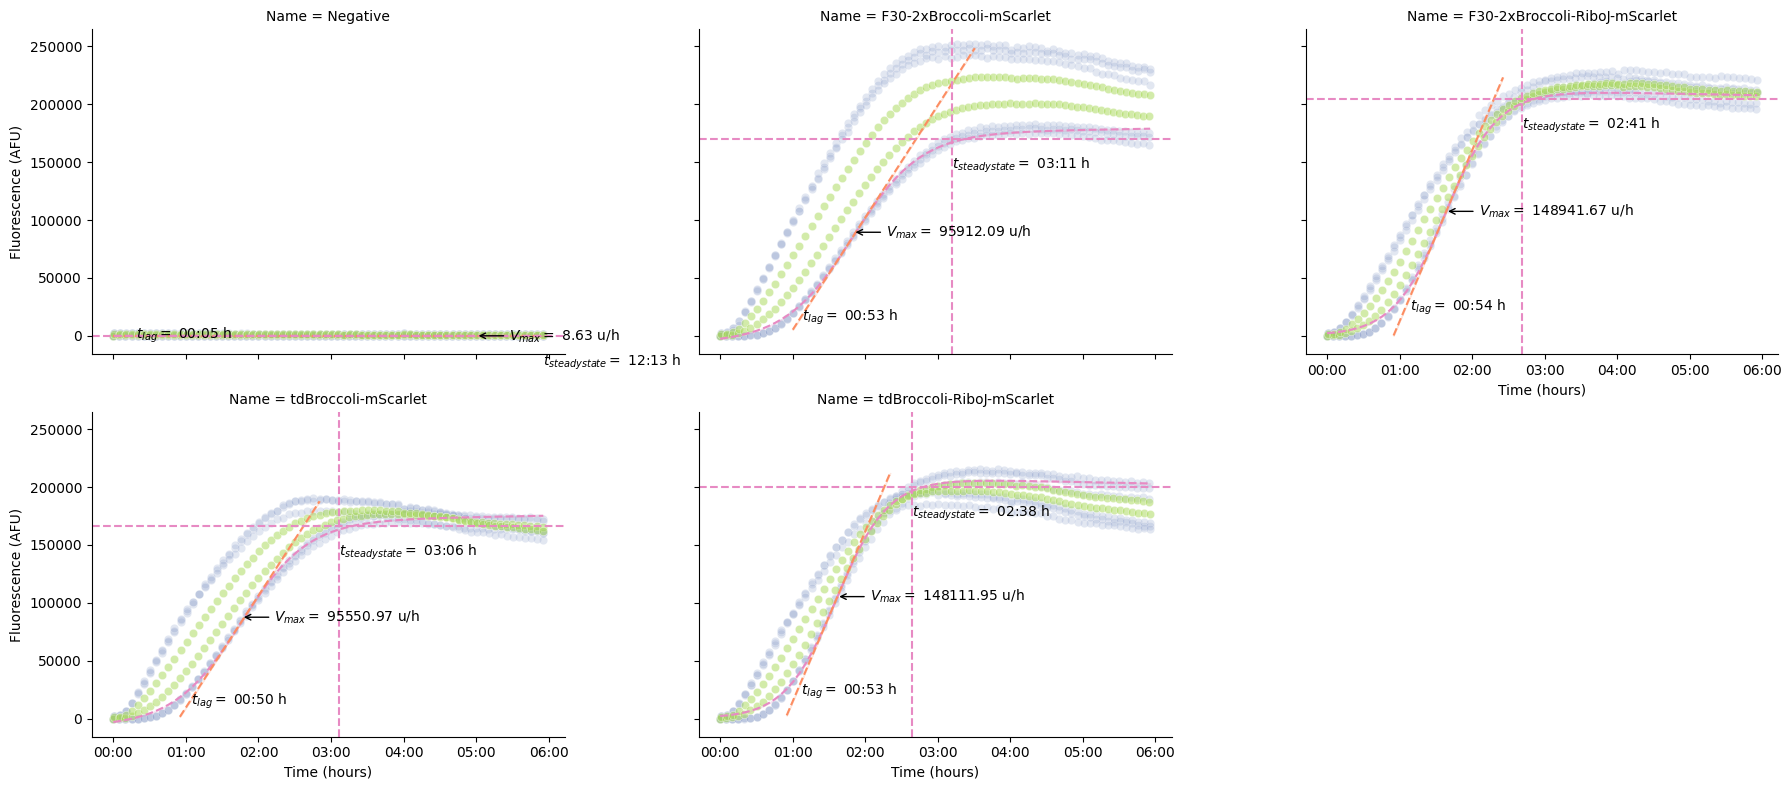

In [12]:
pr.plot_kinetics(data, group_by=["Name", "Read"])

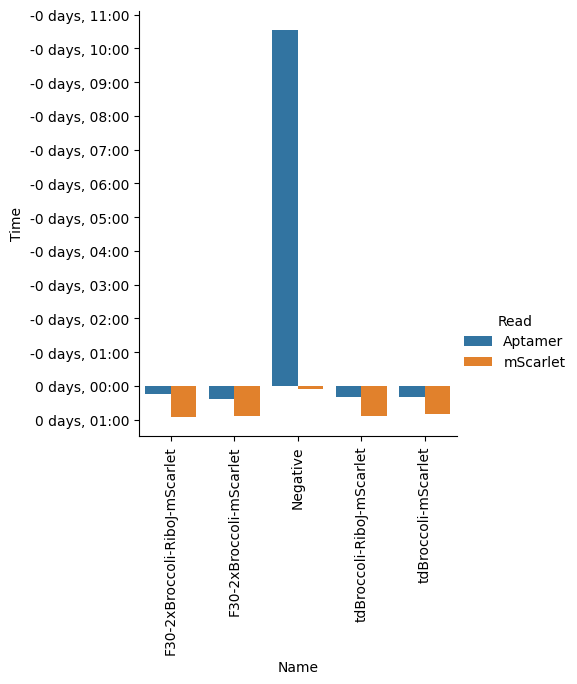

In [13]:
g = sns.catplot(data=lags["Lag"], x="Name", y="Time", hue="Read", kind="bar")
g.set_xticklabels(rotation=90)

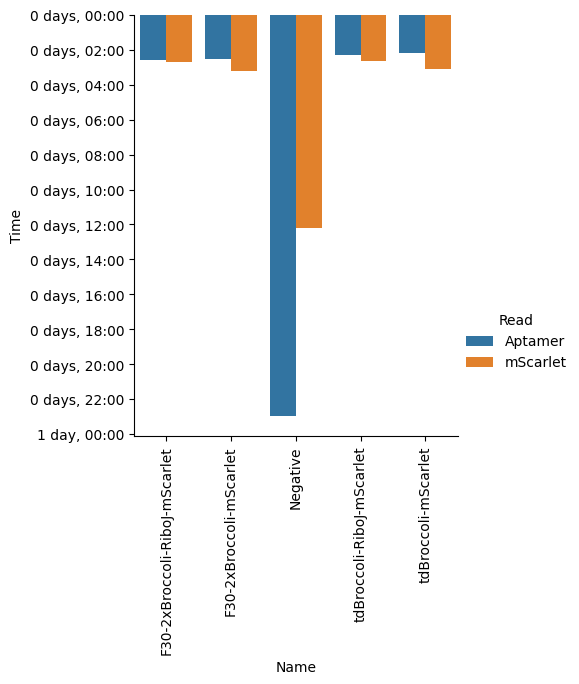

In [14]:
g = sns.catplot(data=lags["Steady State"], x="Name", y="Time", hue="Read", kind="bar")
g.set_xticklabels(rotation=90)